In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression

from sklearn.metrics import accuracy_score, confusion_matrix

In [9]:
from google.colab import files

uploaded = files.upload()

Saving agriculture_yield_dataset.csv to agriculture_yield_dataset.csv


In [11]:
# Load dataset
df = pd.read_csv('agriculture_yield_dataset.csv')

# Number of rows and columns
print("Shape of Dataset:")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns)

# First 10 records
print("\nFirst 10 Records:")
print(df.head(10))

Shape of Dataset:
(1500, 8)

Column Names:
Index(['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours',
       'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare'],
      dtype='object')

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5      

In [12]:
# Data types
print("Data Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [13]:
print(df.describe())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

In [14]:
print(df.mean(numeric_only=True)) #Highest mean

rainfall_mm              754.054667
temperature_c             27.749467
fertilizer_kg            148.744067
irrigation_hours           5.403267
soil_ph                    6.759133
yield_ton_per_hectare      5.028793
dtype: float64


In [15]:
print(df.std(numeric_only=True)) # Highest Standard Deviation Feature

rainfall_mm              255.097216
temperature_c              5.758101
fertilizer_kg             56.990279
irrigation_hours           2.584329
soil_ph                    0.719742
yield_ton_per_hectare      0.968282
dtype: float64


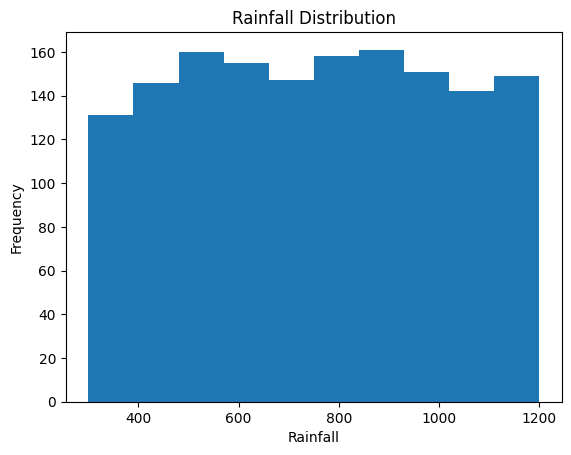

In [16]:
# Histogram of rainfall_mm
plt.hist(df['rainfall_mm'])
plt.title('Rainfall Distribution')
plt.xlabel('Rainfall')
plt.ylabel('Frequency')
plt.show()

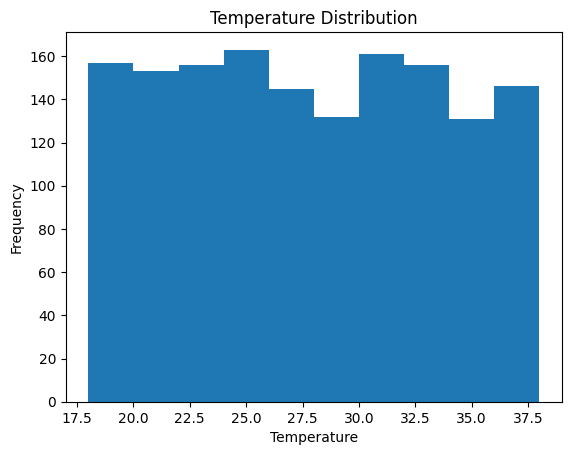

In [17]:
# Histogram of temperature_c
plt.hist(df['temperature_c'])
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

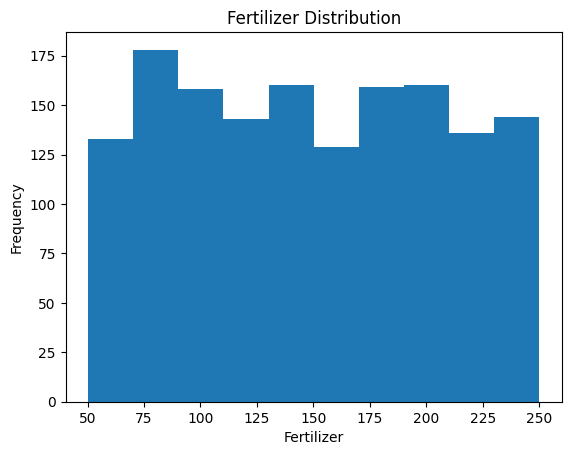

In [18]:
# Histogram of fertilizer_kg
plt.hist(df['fertilizer_kg'])
plt.title('Fertilizer Distribution')
plt.xlabel('Fertilizer')
plt.ylabel('Frequency')
plt.show()

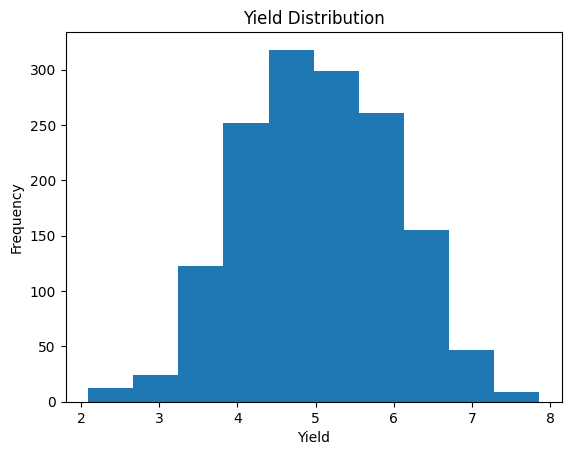

In [19]:
# Histogram of yield_ton_per_hectare
plt.hist(df['yield_ton_per_hectare'])
plt.title('Yield Distribution')
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


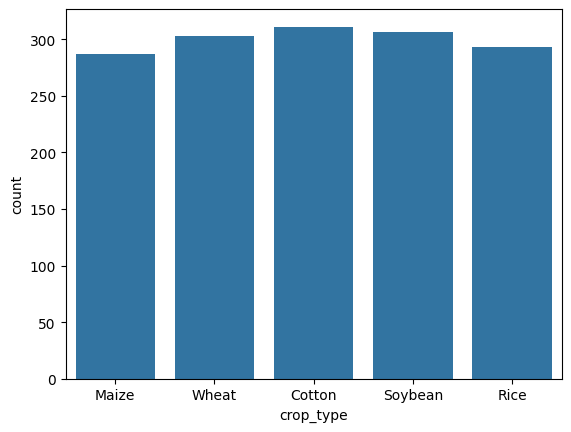

0    Cotton
Name: crop_type, dtype: object


In [24]:
# Number of records for each crop
print(df['crop_type'].value_counts())
# Count Plot
sns.countplot(x='crop_type', data=df)
plt.show()
# Most Frequent Crop
print(df['crop_type'].mode())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


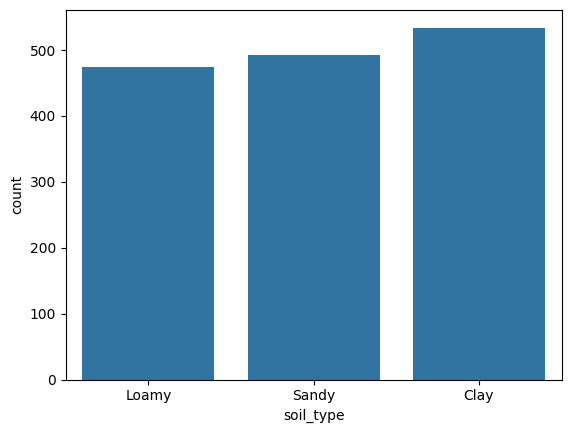

0    Clay
Name: soil_type, dtype: object


In [25]:
# Soil Type Analysis
# Frequency of soil types
print(df['soil_type'].value_counts())
# Count Plot
sns.countplot(x='soil_type', data=df)
plt.show()
# Most Common Soil
print(df['soil_type'].mode())

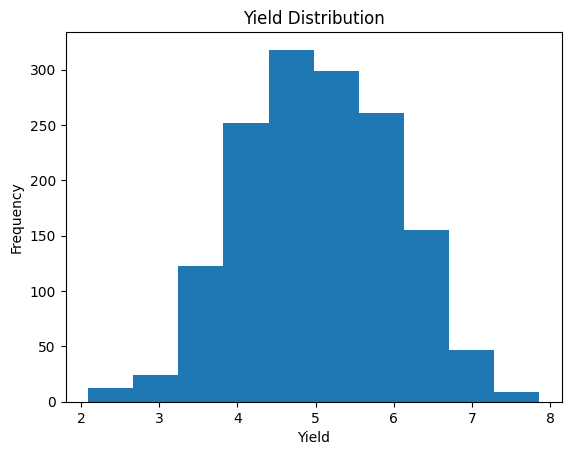

In [26]:
# Yield Distribution
plt.hist(df['yield_ton_per_hectare'])
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.title("Yield Distribution")
plt.show()

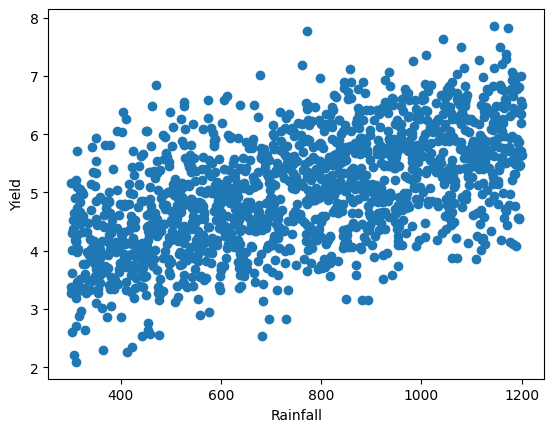

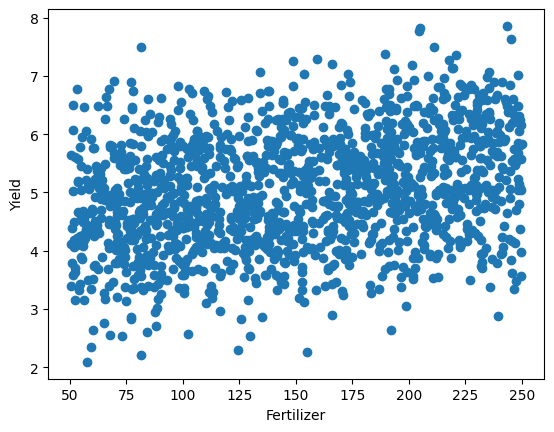

In [27]:
# Scatter Plot Analysis
# rainfall_mm vs yield
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.xlabel('Rainfall')
plt.ylabel('Yield')
plt.show()
# fertilizer_kg vs yield
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.xlabel('Fertilizer')
plt.ylabel('Yield')
plt.show()

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

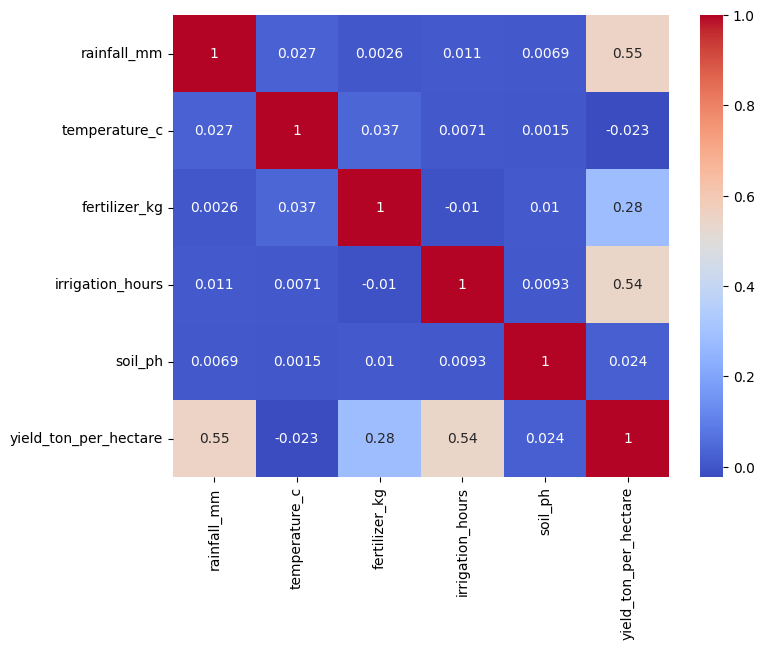

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [28]:
# Correlation Matrix and Heatmap
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix)

# Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm')

plt.show()

# Top 3 features correlated with yield

correlation_with_yield = corr_matrix['yield_ton_per_hectare']

print(correlation_with_yield.sort_values(ascending=False))

In [29]:
# Group-Based Analysis
# Average Yield by Crop Type
crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()

print(crop_avg)
# Average Yield by Soil Type
soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()

print(soil_avg)

# Highest Yield Crop:

print(crop_avg.idxmax())

# Highest Yield Soil:

print(soil_avg.idxmax())

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64
Rice
Loamy


In [30]:
# Feature Encoding

# Identify categorical columns

print(df.select_dtypes(include='object').columns)

# One-Hot Encoding

df_encoded = pd.get_dummies(df)

print(df_encoded.head())

Index(['crop_type', 'soil_type'], dtype='object')
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Cotton  crop_type_Maize  crop_type_Rice  \
0                   5.92             False             True           False   
1                   6.24             False             True           False   
2                   4.77             False            False           False   
3                   4.04             False             True           False   
4                   5.17              True            False           False   

   crop_type_Soybean  cr

In [32]:
# Feature Selection

# Input Features X

X = df_encoded.drop('yield_ton_per_hectare',axis=1)

# Target Variable y

y = df_encoded['yield_ton_per_hectare']

print("Target Variable:")
print(y.name)

Target Variable:
yield_ton_per_hectare


In [36]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Display Shapes

print("X_train Shape =", X_train.shape)

print("X_test Shape =", X_test.shape)

print("y_train Shape =", y_train.shape)

print("y_test Shape =", y_test.shape)



X_train Shape = (1200, 13)
X_test Shape = (300, 13)
y_train Shape = (1200,)
y_test Shape = (300,)


In [37]:
# Linear Regression Model

# Train Model

model = LinearRegression()

model.fit(X_train, y_train)

# Intercept

print("Intercept:")
print(model.intercept_)

# Coefficients

coefficients = pd.DataFrame(
    {
        'Feature': X.columns,
        'Coefficient': model.coef_
    }
)

print(coefficients)

# Highest Positive Coefficient

highest_feature = coefficients.loc[
    coefficients['Coefficient'].idxmax()
]

print(highest_feature)

Intercept:
1.9111026182800726
              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5    crop_type_Cotton    -0.386623
6     crop_type_Maize    -0.147693
7      crop_type_Rice     0.477369
8   crop_type_Soybean     0.095096
9     crop_type_Wheat    -0.038149
10     soil_type_Clay     0.062653
11    soil_type_Loamy     0.365627
12    soil_type_Sandy    -0.428280
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
